In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.inspection import permutation_importance

import statsmodels.api as sm

sns.set_style("whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    print(root)
    print(files[:5])
    break

/content/drive/MyDrive
['Week 2: Reading Preparation.gdoc', 'Ahmed Niazy 202300852 - Week 2 Prompt.gdoc', '20230808_173111.jpg', 'Untitled document (7).gdoc', 'Presentation 16 (2).gslides']


In [ ]:
import zipfile
zip_path = "/content/drive/MyDrive/Data.zip"

extract_path = "/content/Data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
for root, dirs, files in os.walk("/content/Data"):
    print("FOLDER:", root)
    print("FILES:", files[:5])
    print("-----")

FOLDER: /content/Data
FILES: []
-----
FOLDER: /content/Data/Data
FILES: []
-----
FOLDER: /content/Data/Data/Data
FILES: []
-----
FOLDER: /content/Data/Data/Data/dataset_split
FILES: []
-----
FOLDER: /content/Data/Data/Data/dataset_split/test
FILES: ['test.csv']
-----
FOLDER: /content/Data/Data/Data/dataset_split/test/images
FILES: ['img07409.jpg', 'img03113.jpg', 'img04307.jpg', 'img10300.jpg', 'img08219.jpg']
-----
FOLDER: /content/Data/Data/Data/dataset_split/train
FILES: ['train.csv']
-----
FOLDER: /content/Data/Data/Data/dataset_split/train/images
FILES: ['img08078.jpg', 'img13754.jpg', 'img15396.jpg', 'img02463.jpg', 'img01014.jpg']
-----
FOLDER: /content/Data/Data/Data/dataset_split/val
FILES: ['val.csv']
-----
FOLDER: /content/Data/Data/Data/dataset_split/val/images
FILES: ['img10653.jpg', 'img03463.jpg', 'img15257.jpg', 'img11419.jpg', 'img06433.jpg']
-----


In [ ]:
os.listdir("/content/Data")

['Data']

In [ ]:
BASE_PATH = "/content/Data/Data/Data/dataset_split"

TRAIN_CSV = f"{BASE_PATH}/train/train.csv"
VAL_CSV   = f"{BASE_PATH}/val/val.csv"
TEST_CSV  = f"{BASE_PATH}/test/test.csv"

TRAIN_IMG = f"{BASE_PATH}/train/images"
VAL_IMG   = f"{BASE_PATH}/val/images"
TEST_IMG  = f"{BASE_PATH}/test/images"

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (13015, 34)
Val shape: (1632, 34)
Test shape: (1619, 34)


,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality
0,img00001,1,Canon CR,48.0,diabetes1,12,yes,1,1,yes,...,0,0,0,0,0,0,0,1,0,Adequate
1,img00002,1,Canon CR,48.0,diabetes1,12,yes,1,2,yes,...,0,0,0,0,0,0,0,1,0,Adequate
2,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
3,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
4,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate


In [ ]:
print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (13015, 34)
Val shape: (1632, 34)
Test shape: (1619, 34)


,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality
0,img00001,1,Canon CR,48.0,diabetes1,12,yes,1,1,yes,...,0,0,0,0,0,0,0,1,0,Adequate
1,img00002,1,Canon CR,48.0,diabetes1,12,yes,1,2,yes,...,0,0,0,0,0,0,0,1,0,Adequate
2,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
3,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
4,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate


In [ ]:
train_df.columns.tolist()

['image_id',
 'patient_id',
 'camera',
 'patient_age',
 'comorbidities',
 'diabetes_time_y',
 'insuline',
 'patient_sex',
 'exam_eye',
 'diabetes',
 'nationality',
 'optic_disc',
 'vessels',
 'macula',
 'DR_SDRG',
 'DR_ICDR',
 'focus',
 'Illuminaton',
 'image_field',
 'artifacts',
 'diabetic_retinopathy',
 'macular_edema',
 'scar',
 'nevus',
 'amd',
 'vascular_occlusion',
 'hypertensive_retinopathy',
 'drusens',
 'hemorrhage',
 'retinal_detachment',
 'myopic_fundus',
 'increased_cup_disc',
 'other',
 'quality']

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13015 entries, 0 to 13014
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   image_id                  13015 non-null  object 
 1   patient_id                13015 non-null  int64  
 2   camera                    13015 non-null  object 
 3   patient_age               8669 non-null   float64
 4   comorbidities             6396 non-null   object 
 5   diabetes_time_y           1545 non-null   object 
 6   insuline                  1381 non-null   object 
 7   patient_sex               13015 non-null  int64  
 8   exam_eye                  13015 non-null  int64  
 9   diabetes                  13015 non-null  object 
 10  nationality               13015 non-null  object 
 11  optic_disc                13015 non-null  int64  
 12  vessels                   13015 non-null  int64  
 13  macula                    13015 non-null  int64  
 14  DR_SDR

In [ ]:
train_df.isna().sum()

,0
image_id,0
patient_id,0
camera,0
patient_age,4346
comorbidities,6619
diabetes_time_y,11470
insuline,11634
patient_sex,0
exam_eye,0
diabetes,0


In [ ]:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
# ==========================================
# CLEAN NUMERIC CONVERSION (ONLY ONCE)
# ==========================================

for df in [train_df, val_df, test_df]:
    df["patient_age"] = pd.to_numeric(df["patient_age"], errors="coerce")
    df["diabetes_time_y"] = pd.to_numeric(df["diabetes_time_y"], errors="coerce")

In [ ]:
# train_df["patient_age"] = pd.to_numeric(train_df["patient_age"], errors="coerce")
# train_df["diabetes_time_y"] = pd.to_numeric(train_df["diabetes_time_y"], errors="coerce")

# val_df["patient_age"] = pd.to_numeric(val_df["patient_age"], errors="coerce")
# val_df["diabetes_time_y"] = pd.to_numeric(val_df["diabetes_time_y"], errors="coerce")

# test_df["patient_age"] = pd.to_numeric(test_df["patient_age"], errors="coerce")
# test_df["diabetes_time_y"] = pd.to_numeric(test_df["diabetes_time_y"], errors="coerce")

In [ ]:
age_median = train_df["patient_age"].median()
diabetes_time_median = train_df["diabetes_time_y"].median()

for df in [train_df, val_df, test_df]:
    df["patient_age"] = df["patient_age"].fillna(age_median)
    df["diabetes_time_y"] = df["diabetes_time_y"].fillna(diabetes_time_median)
    df["insuline"] = df["insuline"].fillna("unknown")
    df["comorbidities"] = df["comorbidities"].fillna("unknown")

In [ ]:
train_df["image_path"] = train_df["image_id"].apply(lambda x: os.path.join(TRAIN_IMG, f"{x}.jpg"))
val_df["image_path"]   = val_df["image_id"].apply(lambda x: os.path.join(VAL_IMG, f"{x}.jpg"))
test_df["image_path"]  = test_df["image_id"].apply(lambda x: os.path.join(TEST_IMG, f"{x}.jpg"))

In [ ]:
print(train_df["image_path"].apply(os.path.exists).value_counts())
print(val_df["image_path"].apply(os.path.exists).value_counts())
print(test_df["image_path"].apply(os.path.exists).value_counts())

image_path
True    13015
Name: count, dtype: int64
image_path
True    1632
Name: count, dtype: int64
image_path
True    1619
Name: count, dtype: int64


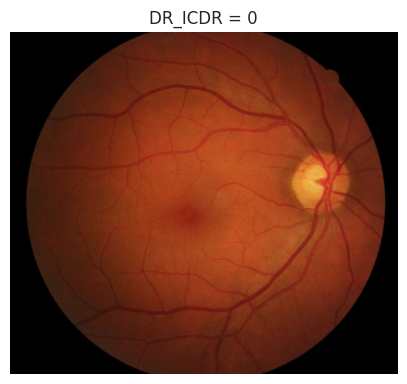

In [ ]:
sample_path = train_df.iloc[0]["image_path"]
sample_img = Image.open(sample_path)

plt.figure(figsize=(5,5))
plt.imshow(sample_img)
plt.axis("off")
plt.title(f'DR_ICDR = {train_df.iloc[0]["DR_ICDR"]}')
plt.show()

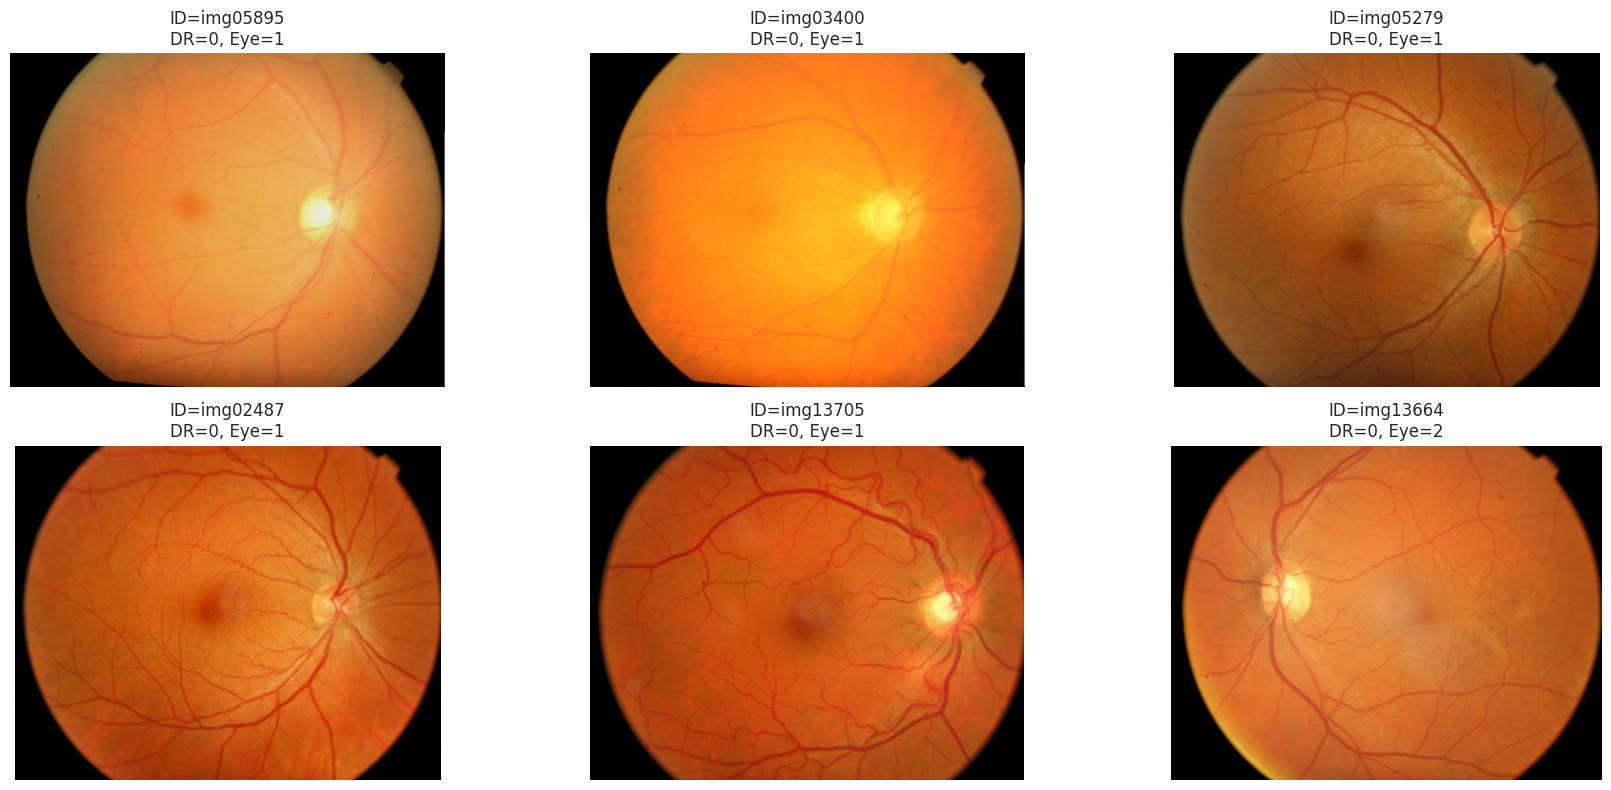

In [ ]:
def show_samples(df, n=6):
    samples = df.sample(n, random_state=42)
    plt.figure(figsize=(18, 8))

    for i, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row["image_path"])
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f'ID={row["image_id"]}\nDR={row["DR_ICDR"]}, Eye={row["exam_eye"]}')
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_df, n=6)

In [ ]:
train_df["DR_ICDR"].value_counts().sort_index()

,count
DR_ICDR,
0,12151
1,124
2,357
3,66
4,317


In [ ]:
train_df["DR_ICDR"].value_counts(normalize=True).sort_index()

,proportion
DR_ICDR,
0,0.933615
1,0.009527
2,0.027430
3,0.005071
4,0.024357


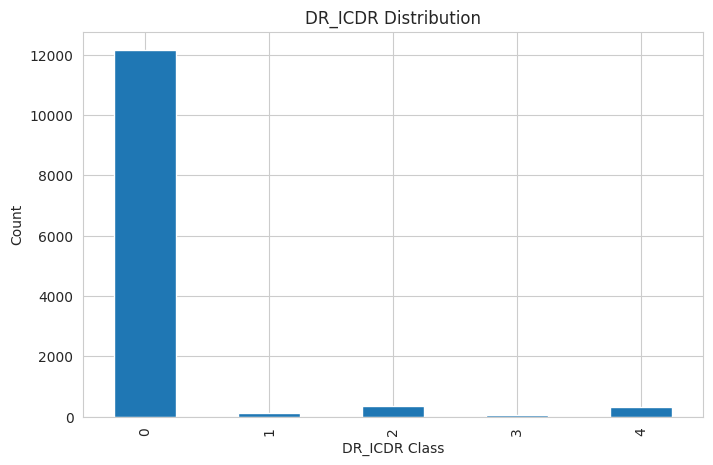

In [ ]:
plt.figure(figsize=(8,5))
train_df["DR_ICDR"].value_counts().sort_index().plot(kind="bar")
plt.title("DR_ICDR Distribution")
plt.xlabel("DR_ICDR Class")
plt.ylabel("Count")
plt.show()

In [ ]:
train_df["macular_edema"].value_counts(dropna=False)

,count
macular_edema,
0,12694
1,321


In [ ]:
train_df["diabetic_retinopathy"].value_counts(dropna=False)

,count
diabetic_retinopathy,
0,12159
1,856


In [ ]:
print("Unique patients in train:", train_df["patient_id"].nunique())
print("Unique patients in val:", val_df["patient_id"].nunique())
print("Unique patients in test:", test_df["patient_id"].nunique())

Unique patients in train: 6819
Unique patients in val: 852
Unique patients in test: 853


In [ ]:
train_df.groupby("patient_id")["exam_eye"].count().value_counts()

,count
exam_eye,
2,6165
1,642
4,7
3,5


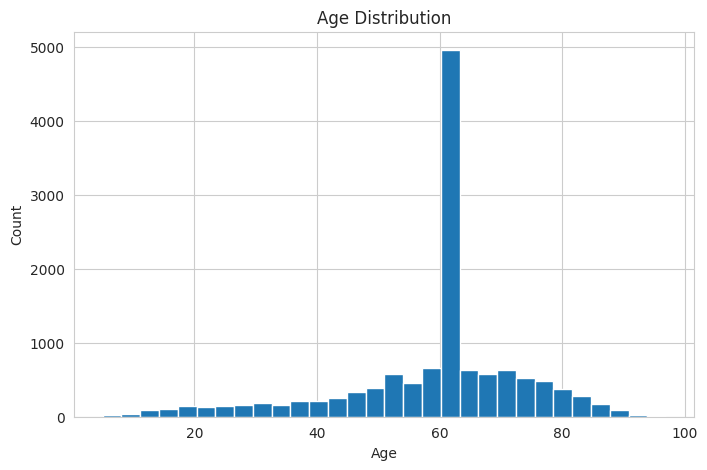

In [ ]:
plt.figure(figsize=(8,5))
train_df["patient_age"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

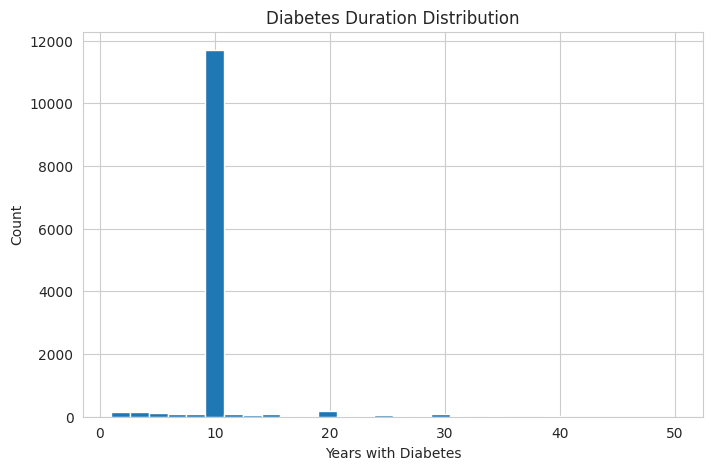

In [ ]:
plt.figure(figsize=(8,5))
train_df["diabetes_time_y"].hist(bins=30)
plt.title("Diabetes Duration Distribution")
plt.xlabel("Years with Diabetes")
plt.ylabel("Count")
plt.show()

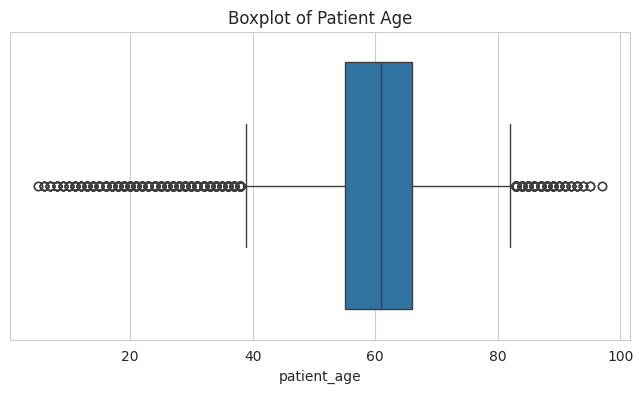

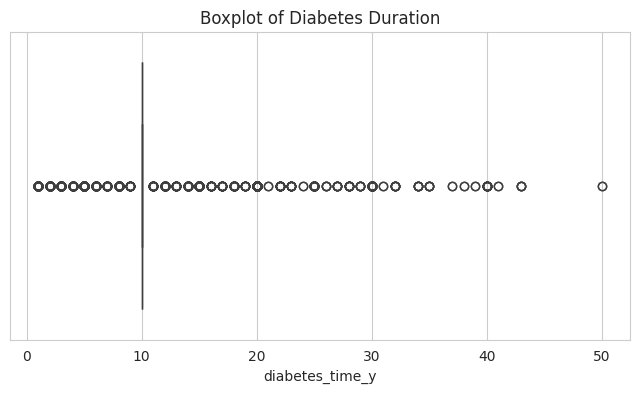

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=train_df["patient_age"])
plt.title("Boxplot of Patient Age")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=train_df["diabetes_time_y"])
plt.title("Boxplot of Diabetes Duration")
plt.show()

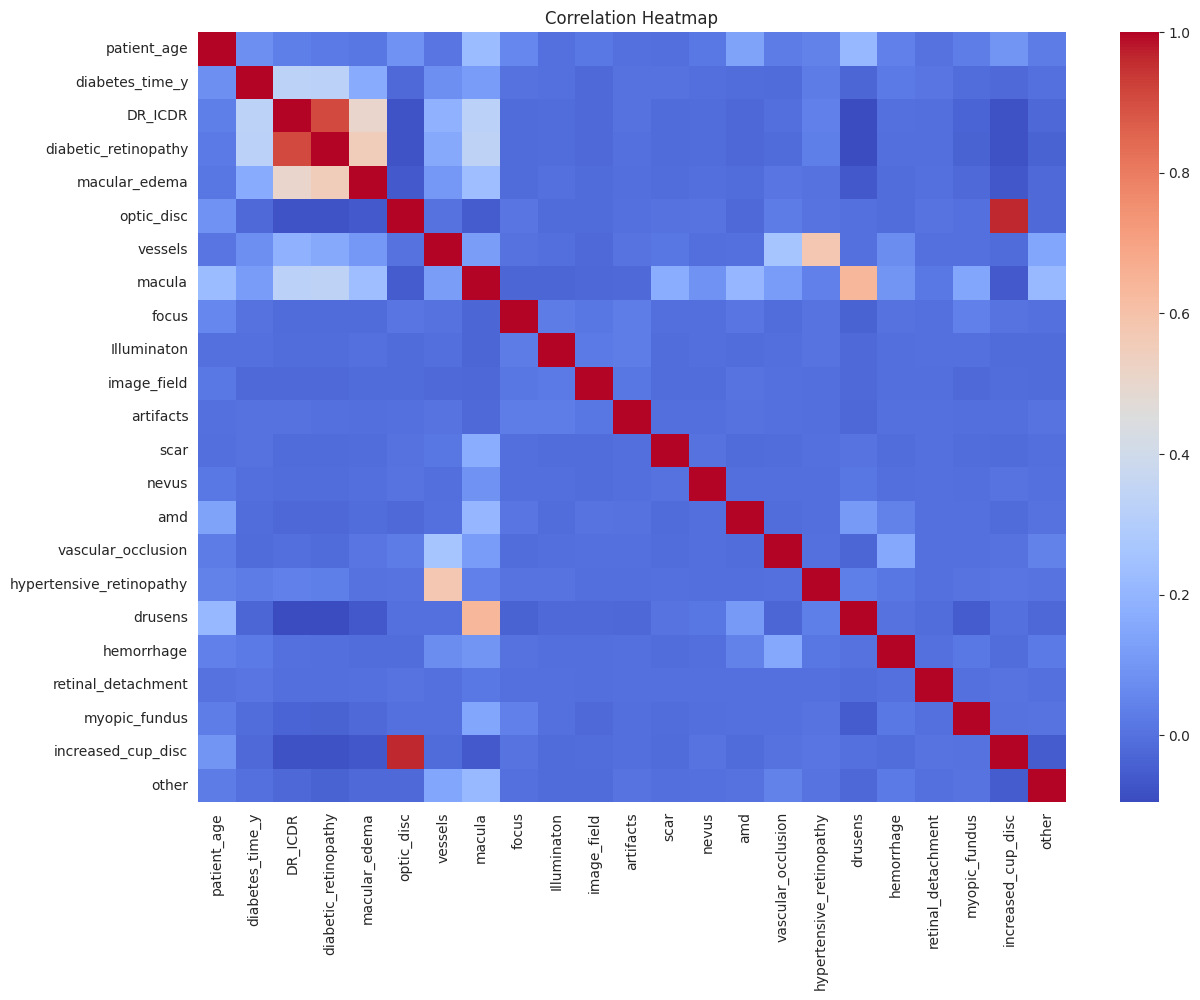

In [ ]:
numeric_cols = [
    "patient_age",
    "diabetes_time_y",
    "DR_ICDR",
    "diabetic_retinopathy",
    "macular_edema",
    "optic_disc",
    "vessels",
    "macula",
    "focus",
    "Illuminaton",
    "image_field",
    "artifacts",
    "scar",
    "nevus",
    "amd",
    "vascular_occlusion",
    "hypertensive_retinopathy",
    "drusens",
    "hemorrhage",
    "retinal_detachment",
    "myopic_fundus",
    "increased_cup_disc",
    "other"
]

numeric_cols = [col for col in numeric_cols if col in train_df.columns]

plt.figure(figsize=(14,10))
sns.heatmap(train_df[numeric_cols].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
train_df[numeric_cols].corr()["DR_ICDR"].sort_values(ascending=False)

,DR_ICDR
DR_ICDR,1.000000
diabetic_retinopathy,0.909921
macular_edema,0.507590
diabetes_time_y,0.330998
macula,0.325813
vessels,0.186320
hypertensive_retinopathy,0.040184
patient_age,0.035865
artifacts,0.000386
hemorrhage,-0.003195


In [ ]:
categorical_cols = [
    "camera",
    "comorbidities",
    "insuline",
    "patient_sex",
    "exam_eye",
    "diabetes",
    "nationality",
    "quality"
]

categorical_cols = [col for col in categorical_cols if col in train_df.columns]
categorical_cols

['camera',
 'comorbidities',
 'insuline',
 'patient_sex',
 'exam_eye',
 'diabetes',
 'nationality',
 'quality']

In [ ]:
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    val_df[col]   = val_df[col].astype(str).map(lambda x: x if x in le.classes_ else le.classes_[0])
    test_df[col]  = test_df[col].astype(str).map(lambda x: x if x in le.classes_ else le.classes_[0])

    mapping = {cls: idx for idx, cls in enumerate(le.classes_)}
    val_df[col] = val_df[col].map(mapping)
    test_df[col] = test_df[col].map(mapping)

    encoders[col] = le

In [ ]:
drop_cols = ["image_id", "image_path", "patient_id"]

target_col = "DR_ICDR"

feature_cols = [col for col in train_df.columns if col not in drop_cols + [target_col]]
feature_cols

['camera',
 'patient_age',
 'comorbidities',
 'diabetes_time_y',
 'insuline',
 'patient_sex',
 'exam_eye',
 'diabetes',
 'nationality',
 'optic_disc',
 'vessels',
 'macula',
 'DR_SDRG',
 'focus',
 'Illuminaton',
 'image_field',
 'artifacts',
 'diabetic_retinopathy',
 'macular_edema',
 'scar',
 'nevus',
 'amd',
 'vascular_occlusion',
 'hypertensive_retinopathy',
 'drusens',
 'hemorrhage',
 'retinal_detachment',
 'myopic_fundus',
 'increased_cup_disc',
 'other',
 'quality']

In [ ]:
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

In [ ]:
# ========================================
# ⚙️ Feature Engineering & Selection
# ========================================

In [ ]:
# Ensure all features are numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_val   = X_val.apply(pd.to_numeric, errors='coerce')
X_test  = X_test.apply(pd.to_numeric, errors='coerce')

# Fill NaNs created from conversion
X_train = X_train.fillna(0)
X_val   = X_val.fillna(0)
X_test  = X_test.fillna(0)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

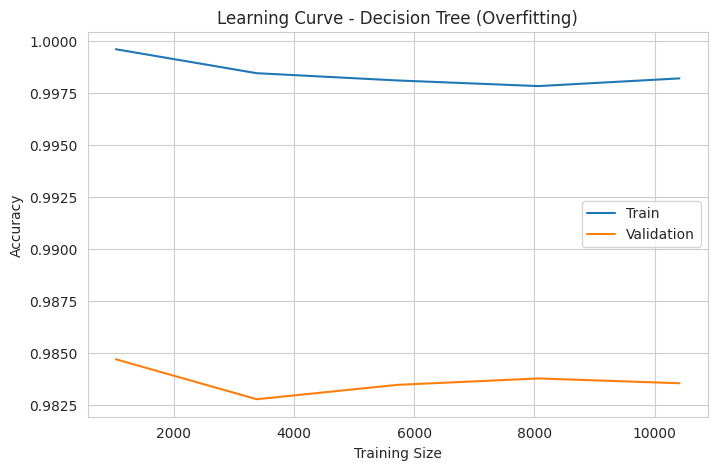

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier
import numpy as np

dt = DecisionTreeClassifier(random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    dt,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, val_mean, label="Validation")
plt.title("Learning Curve - Decision Tree (Overfitting)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

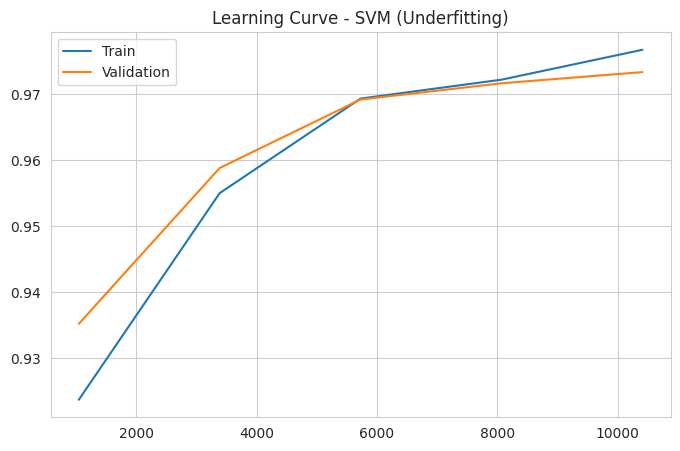

In [ ]:
from sklearn.svm import SVC

svm = SVC(C=0.1)

train_sizes, train_scores, val_scores = learning_curve(
    svm,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
plt.title("Learning Curve - SVM (Underfitting)")
plt.legend()
plt.show()

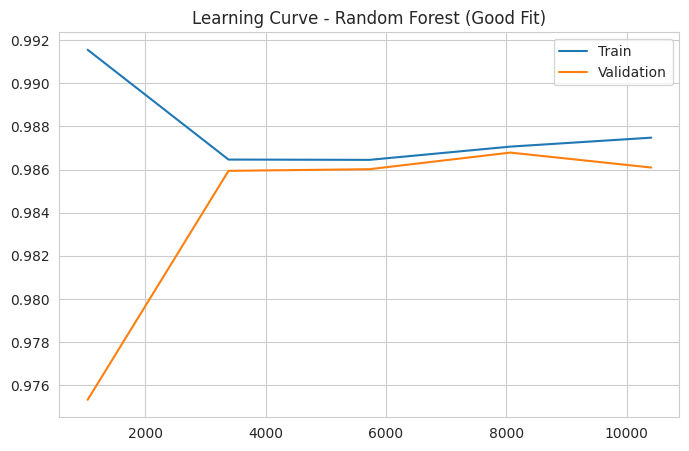

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_temp = RandomForestClassifier(max_depth=5, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    rf_temp,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
plt.title("Learning Curve - Random Forest (Good Fit)")
plt.legend()
plt.show()

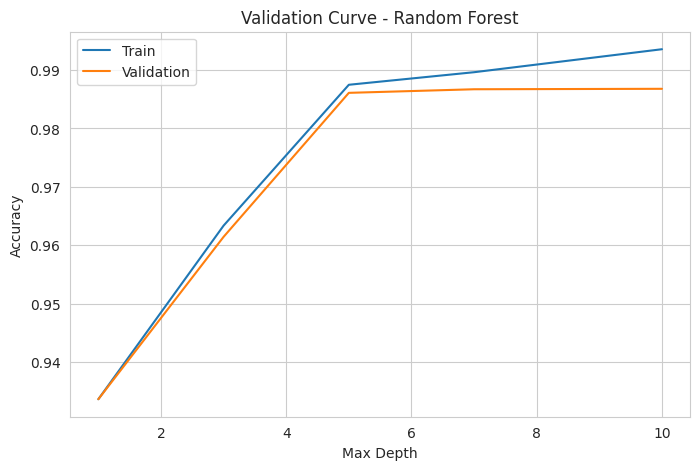

In [ ]:
from sklearn.model_selection import validation_curve

param_range = [1, 3, 5, 7, 10]

train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    X_train_scaled,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

plt.figure(figsize=(8,5))
plt.plot(param_range, train_scores.mean(axis=1), label="Train")
plt.plot(param_range, val_scores.mean(axis=1), label="Validation")
plt.title("Validation Curve - Random Forest")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

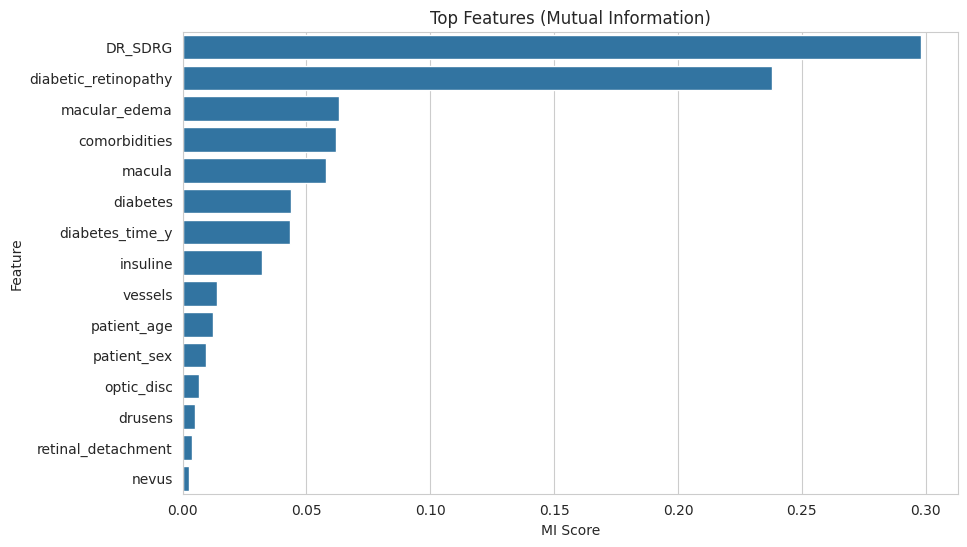

In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train, y_train)

mi_df = pd.DataFrame({
    "Feature": feature_cols,
    "MI Score": mi_scores
}).sort_values(by="MI Score", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=mi_df.head(15), x="MI Score", y="Feature")
plt.title("Top Features (Mutual Information)")
plt.show()

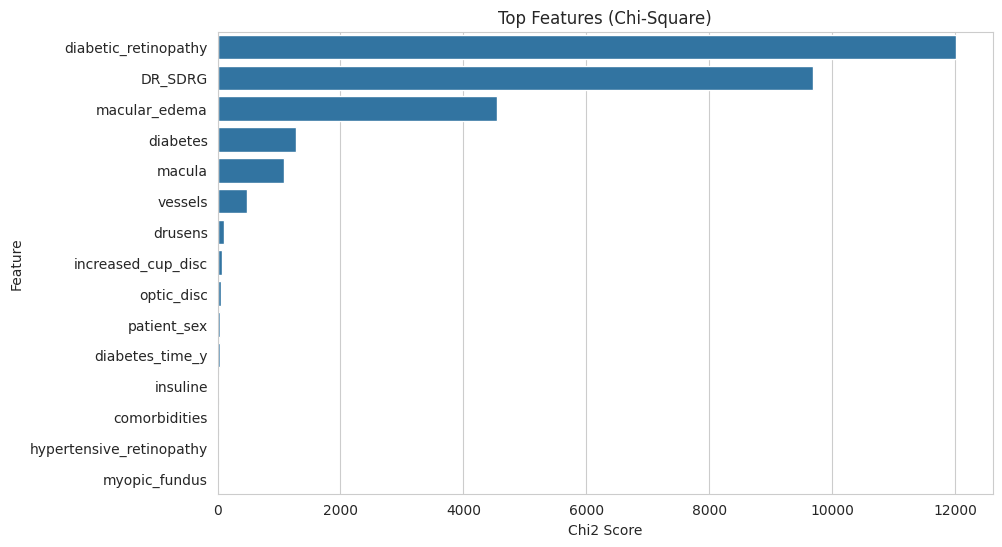

In [ ]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

scaler_chi = MinMaxScaler()
X_train_nonneg = scaler_chi.fit_transform(X_train)

chi_scores, _ = chi2(X_train_nonneg, y_train)

chi_df = pd.DataFrame({
    "Feature": feature_cols,
    "Chi2 Score": chi_scores
}).sort_values(by="Chi2 Score", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=chi_df.head(15), x="Chi2 Score", y="Feature")
plt.title("Top Features (Chi-Square)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


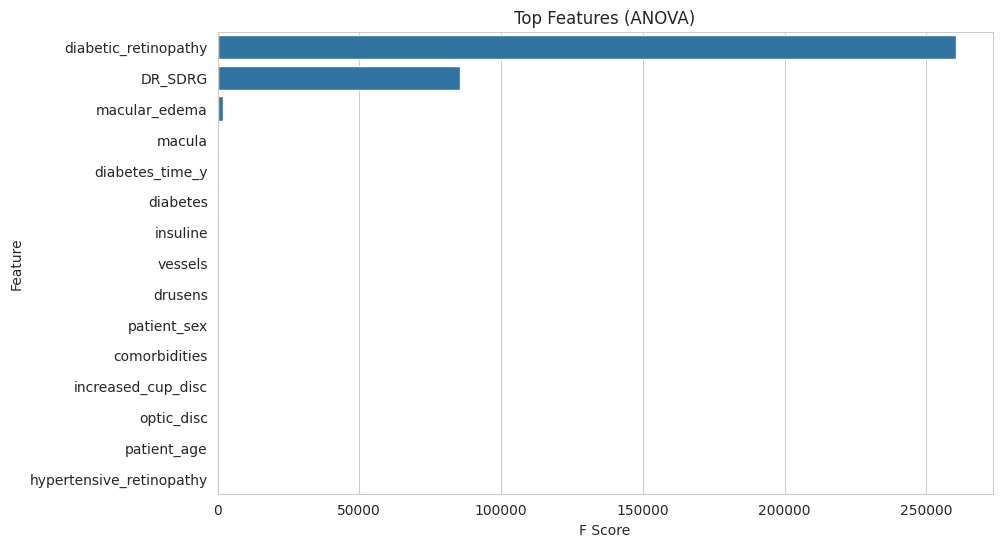

In [ ]:
from sklearn.feature_selection import f_classif

f_scores, _ = f_classif(X_train, y_train)

f_df = pd.DataFrame({
    "Feature": feature_cols,
    "F Score": f_scores
}).sort_values(by="F Score", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=f_df.head(15), x="F Score", y="Feature")
plt.title("Top Features (ANOVA)")
plt.show()

In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)

selected_features_var = X_train.columns[selector.get_support()]

print("Features kept after variance threshold:", len(selected_features_var))

Features kept after variance threshold: 24


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


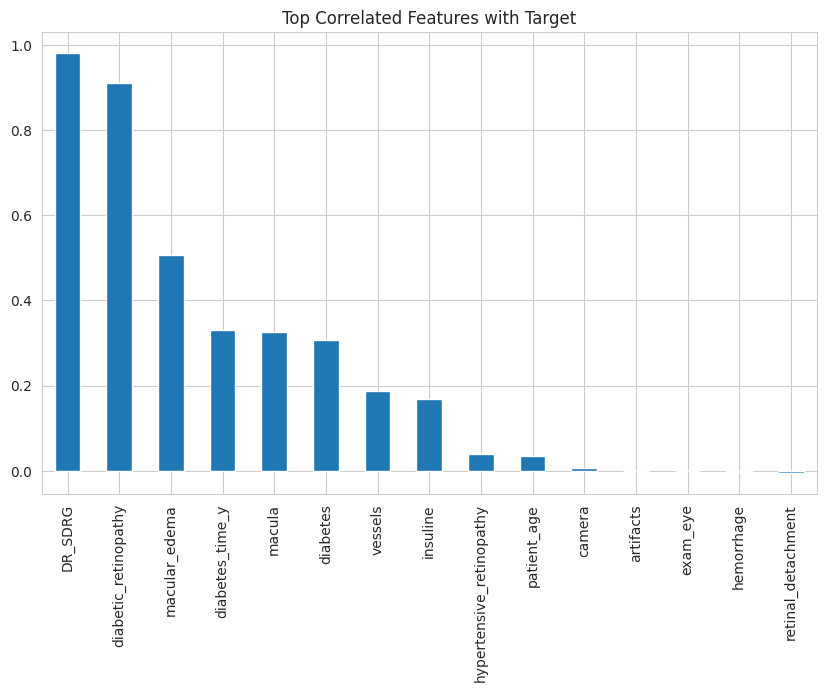

In [ ]:
corr_target = train_df[feature_cols].corrwith(train_df[target_col])

corr_target = corr_target.sort_values(ascending=False)

plt.figure(figsize=(10,6))
corr_target.head(15).plot(kind='bar')
plt.title("Top Correlated Features with Target")
plt.show()

In [ ]:
selected_features = mi_df.head(20)["Feature"].tolist()

In [ ]:
X_train = X_train[selected_features]
X_val   = X_val[selected_features]
X_test  = X_test[selected_features]

SyntaxError: invalid syntax (4086919973.py, line 4)

In [ ]:
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_val   = X_val.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test  = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

# Check types
print(X_train.dtypes.value_counts())

int64      18
float64     2
Name: count, dtype: int64


In [ ]:
feature_cols = selected_features

X_train = X_train[feature_cols]
X_val   = X_val[feature_cols]
X_test  = X_test[feature_cols]

In [ ]:
!pip install xgboost shap -q

import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(y_train.unique()),
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_class=5, ...)

In [ ]:
y_val_pred = xgb_model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.9901960784313726
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1544
           1       0.64      0.64      0.64        11
           2       0.82      0.82      0.82        44
           3       0.40      0.33      0.36         6
           4       1.00      1.00      1.00        27

    accuracy                           0.99      1632
   macro avg       0.77      0.76      0.76      1632
weighted avg       0.99      0.99      0.99      1632



In [ ]:
y_test_pred = xgb_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.9857936998147004
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1488
           1       0.71      0.74      0.72        23
           2       0.80      0.78      0.79        50
           3       0.00      0.00      0.00         6
           4       1.00      1.00      1.00        52

    accuracy                           0.99      1619
   macro avg       0.70      0.70      0.70      1619
weighted avg       0.98      0.99      0.99      1619



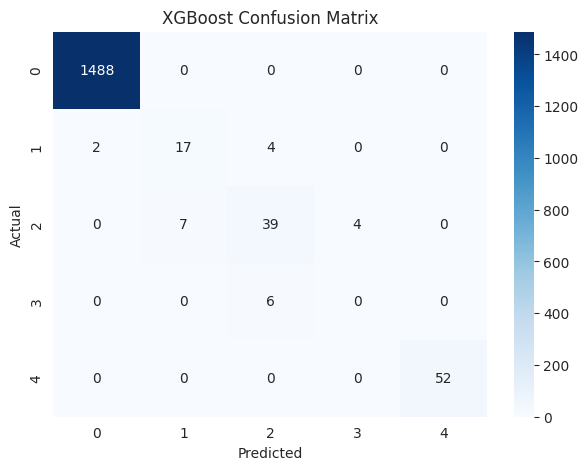

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

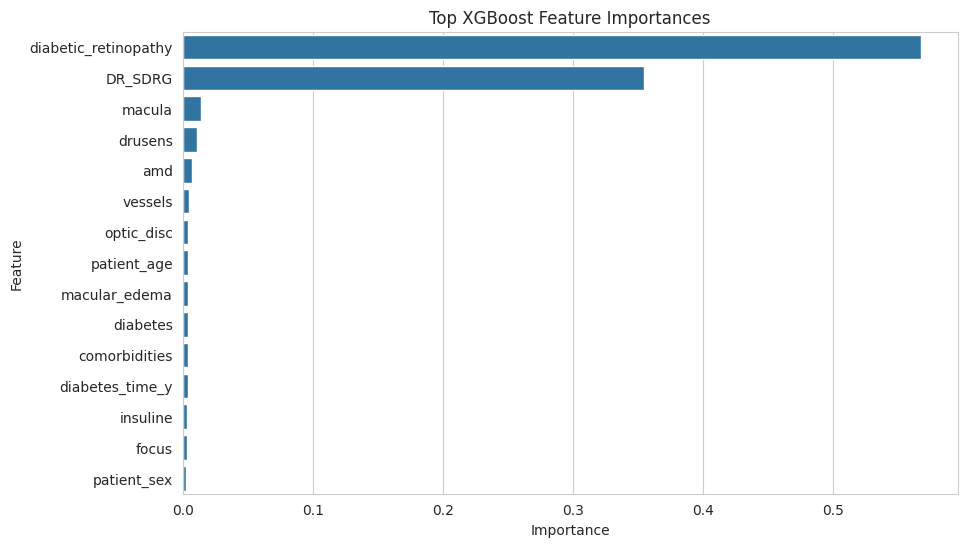

,Feature,Importance
1,diabetic_retinopathy,0.567272
0,DR_SDRG,0.354333
4,macula,0.013963
12,drusens,0.010870
19,amd,0.006837
8,vessels,0.004976
11,optic_disc,0.004408
9,patient_age,0.004314
2,macular_edema,0.004196
5,diabetes,0.004146


In [ ]:
xgb_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=xgb_importance.head(15), x="Importance", y="Feature")
plt.title("Top XGBoost Feature Importances")
plt.show()

xgb_importance.head(15)